In [8]:
import torch
import numpy as np
import anndata as ad
import pertpy
import scanpy as sc
import os
import pickle
from pathlib import Path

from data.space import SpaceManager
from data.dataset import CondFMDataset
from data.splitters import (
    SplitConfig,
    apply_holdout_masks,
    load_manifest_json,
    make_split_artifacts,
    validate_no_leakage,
)
from models.flow import CondFlow, ConditionEncoder
from training.losses import FlowMatchingMSELoss, LossComposer
from training.trainer_flow_matching import train_flow_matching


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
config = SplitConfig()
artifacts = make_split_artifacts(config)

subsample_h5ad_path = Path(f"sciplex_subsample_{artifacts.tag}.h5ad")
ode_metadata_path = Path(f"sciplex_ode_metadata_{artifacts.tag}.pkl")
space_path = Path(f"sciplex_space_{artifacts.tag}.pkl")
fm_model_path = Path(f"sciplex_fm_model_{artifacts.tag}.pt")
fm_metadata_path = Path(f"sciplex_fm_metadata_{artifacts.tag}.pkl")

required = {
    "subsample_h5ad": subsample_h5ad_path,
    "holdout_manifest": artifacts.holdout_json_path,
    "ode_metadata": ode_metadata_path,
    "space": space_path,
}
missing = [f"{name}: {path}" for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts for FM training:\n  - " + "\n  - ".join(missing))

adata = ad.read_h5ad(subsample_h5ad_path)
manifest = load_manifest_json(artifacts.holdout_json_path)

with open(ode_metadata_path, "rb") as f:
    ode_meta = pickle.load(f)

with open(space_path, "rb") as f:
    space = pickle.load(f)

print(f"Using split tag: {artifacts.tag}")


Using split tag: strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle


In [11]:
SEED = config.seed
test_cell_type = config.test_cell_type

masks = apply_holdout_masks(adata, manifest)
validate_no_leakage(adata, masks, product_name_col="product_name")

is_held_out = masks["is_held_out"]
is_pert_any = masks["is_pert_any"]
is_pert_train = masks["is_pert_train"]

held_out_products = manifest["selected_holdout_product_names"]
print(f"held-out products for {test_cell_type}: {held_out_products}")
print(
    f"Train cells: {masks['is_train'].sum()}, "
    f"Held-out perturbed cells: {is_held_out.sum()}, "
    f"Train perturbed cells: {is_pert_train.sum()}"
)

adata_train = adata[masks["is_train"]].copy()


held-out products for K562: ['AG-490 (Tyrphostin B42)', 'AMG-900', 'AR-42', 'AZ 960', 'AZD1480', 'Alendronate sodium trihydrate', 'Alvespimycin (17-DMAG) HCl', 'Anacardic Acid', 'Andarine', 'Aurora A Inhibitor I', 'Avagacestat (BMS-708163)', 'BMS-911543', 'Baricitinib (LY3009104, INCB028050)', 'CEP-33779', 'CYC116', 'Cediranib (AZD2171)', 'Celecoxib', 'Crizotinib (PF-02341066)', 'Dacinostat (LAQ824)', 'Danusertib (PHA-739358)', 'Daphnetin', 'Dasatinib', 'Decitabine', 'Disulfiram ', 'Divalproex Sodium', 'ENMD-2076', 'Ellagic acid', 'Entacapone', 'Enzastaurin (LY317615)', 'FLLL32', 'Fedratinib (SAR302503, TG101348)', 'Filgotinib (GLPG0634)', 'Flavopiridol HCl', 'Fluorouracil (5-Fluoracil, 5-FU)', 'G007-LK', 'GSK-LSD1 2HCl', 'GSK1070916', 'Gandotinib (LY2784544)', 'Glesatinib?(MGCD265)', 'INO-1001 (3-Aminobenzamide)', 'ITSA-1 (ITSA1)', 'Iniparib (BSI-201)', 'Ivosidenib (AG-120)', 'Lenalidomide (CC-5013)', 'Linifanib (ABT-869)', 'Lomustine ', 'Luminespib (AUY-922, NVP-AUY922)', 'M344', 'MK

In [12]:
# reuse vocab from ODE training so both models share identical index mappings
pert_to_idx = ode_meta["pert_to_idx"]
rep_to_idx = ode_meta["rep_to_idx"]
ct_to_idx = ode_meta["ct_to_idx"]

pert_ids = torch.tensor([pert_to_idx[p] for p in adata_train.obs["product_dose"]], dtype=torch.long)
rep_ids = torch.tensor([rep_to_idx[r] for r in adata_train.obs["replicate"]], dtype=torch.long)
ct_ids = torch.tensor([ct_to_idx[ct] for ct in adata_train.obs["cell_type"]], dtype=torch.long)

condition_batch = {
    "perturbations": pert_ids,
    "perturbation_covariates": {},
    "sample_covariates": {
        "replicate": rep_ids,
        "cell_type": ct_ids,
    },
}

adata_train_hvg = adata_train[:, space.hvg_names].copy()
sc.pp.normalize_total(adata_train_hvg, target_sum=1e4)
sc.pp.log1p(adata_train_hvg)

ds = CondFMDataset(
    adata_train_hvg, condition_batch, control_col="vehicle", control_value=1.0, use_pca=False, use_norm=False
)

In [13]:
covariate_dicts = ode_meta["covariate_dicts"]

cond_enc = ConditionEncoder(covariate_dicts=covariate_dicts, embedding_dim=64, condition_dim=128)
model = CondFlow(input_dim=2000, output_dim=2000, hidden_dim=256, hidden_layers=4, cond_encoder=cond_enc).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_composer = LossComposer({"fm_mse": FlowMatchingMSELoss()}, {"fm_mse": 1.0})

history = train_flow_matching(
    model=model,
    dataset=ds,
    loss_composer=loss_composer,
    optimizer=optimizer,
    epochs=400,
    batch_size=2048,
    device=device,
    use_sampler=True,
    steps_per_epoch=100,
)

torch.save(model.state_dict(), fm_model_path)

metadata = {
    "split_tag": artifacts.tag,
    "holdout_manifest_path": str(artifacts.holdout_json_path),
    "subsample_h5ad_path": str(subsample_h5ad_path),
    "pert_to_idx": pert_to_idx,
    "rep_to_idx": rep_to_idx,
    "ct_to_idx": ct_to_idx,
    "covariate_dicts": covariate_dicts,
    "hvg_names": space.hvg_names,
    "mean": ds.mean,
    "std": ds.std,
}
with open(fm_metadata_path, "wb") as f:
    pickle.dump(metadata, f)

print(f"Saved FM model to {fm_model_path}")
print(f"Saved FM metadata to {fm_metadata_path}")


training flow matching model on device: cuda


Epoch 1/400: 100%|██████████| 100/100 [00:00<00:00, 152.59it/s]


epoch 1/400 - train Loss: 0.8577


Epoch 2/400: 100%|██████████| 100/100 [00:00<00:00, 163.70it/s]


epoch 2/400 - train Loss: 0.6836


...

epoch 398/400 - train Loss: 0.4177


Epoch 399/400: 100%|██████████| 100/100 [00:00<00:00, 154.18it/s]


epoch 399/400 - train Loss: 0.4226


Epoch 400/400: 100%|██████████| 100/100 [00:00<00:00, 144.45it/s]

epoch 400/400 - train Loss: 0.4187
Saved FM model to sciplex_fm_model_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pt
Saved FM metadata to sciplex_fm_metadata_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pkl


Text(0.5, 1.0, 'fm train loss')

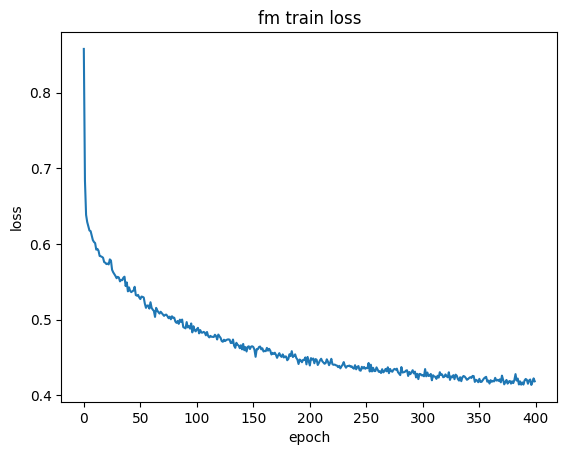

In [14]:
# plot training hist
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("fm train loss")